In [1]:
import pandas as pd
INPUT_FILE_PATH = r"E:\hallucination\Reducing-Hallucinations-in-Clinical-Diagnosis\detectionAG\Research_Paper_Metrics.xlsx"
df_cats = pd.read_excel(INPUT_FILE_PATH, sheet_name="Category_Analysis")
df_model = pd.read_excel(INPUT_FILE_PATH, sheet_name="Model_Overview")
df_log = pd.read_excel(INPUT_FILE_PATH, sheet_name="Hallucination_Log")
df_raw = pd.read_excel(INPUT_FILE_PATH, sheet_name="File_Raw_Data")

print("\n--- Data Successfully Loaded ---")
print(f"df_cats: {df_cats.shape} (Category Analysis)")
print(f"df_model: {df_model.shape} (Model Overview)")
print(f"df_log: {df_log.shape} (Hallucination Log)")
print(f"df_raw: {df_raw.shape} (File Raw Data)")

# Optional: Display first rows to verify
display(df_model.head())


--- Data Successfully Loaded ---
df_cats: (72, 11) (Category Analysis)
df_model: (6, 14) (Model Overview)
df_log: (1356, 9) (Hallucination Log)
df_raw: (282, 12) (File Raw Data)


,Model,Gold_Total,Gold_Covered,Gold_Omitted,Gold_Contradicted,Gen_Total,Gen_Supported,Gen_Contradicted,Gen_Valid_Elaboration,Gen_True_Addition,Gen_Schema_Error,Precision,Recall,Hallucination_Rate
0,gpt-4.1,1251,1026,125,96,2210,1566,127,454,13,4,0.914027,0.820144,0.063348
1,gpt-4.1-mini,1250,972,183,87,2137,1485,131,415,28,5,0.889097,0.777600,0.074403
2,gpt-4o,1257,871,301,85,1660,1198,99,325,6,3,0.917470,0.692920,0.063253
3,gpt-5,593,516,39,38,1166,870,59,219,4,2,0.933962,0.870152,0.054031
4,gpt-5-mini,1229,963,168,96,2178,1530,131,438,38,5,0.903581,0.783564,0.077594


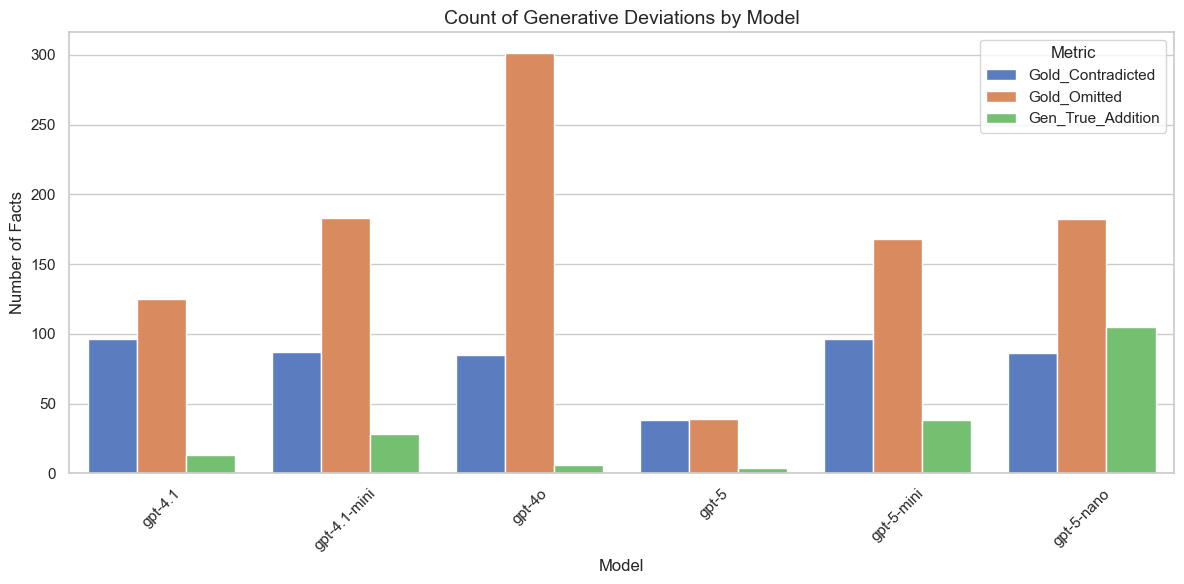

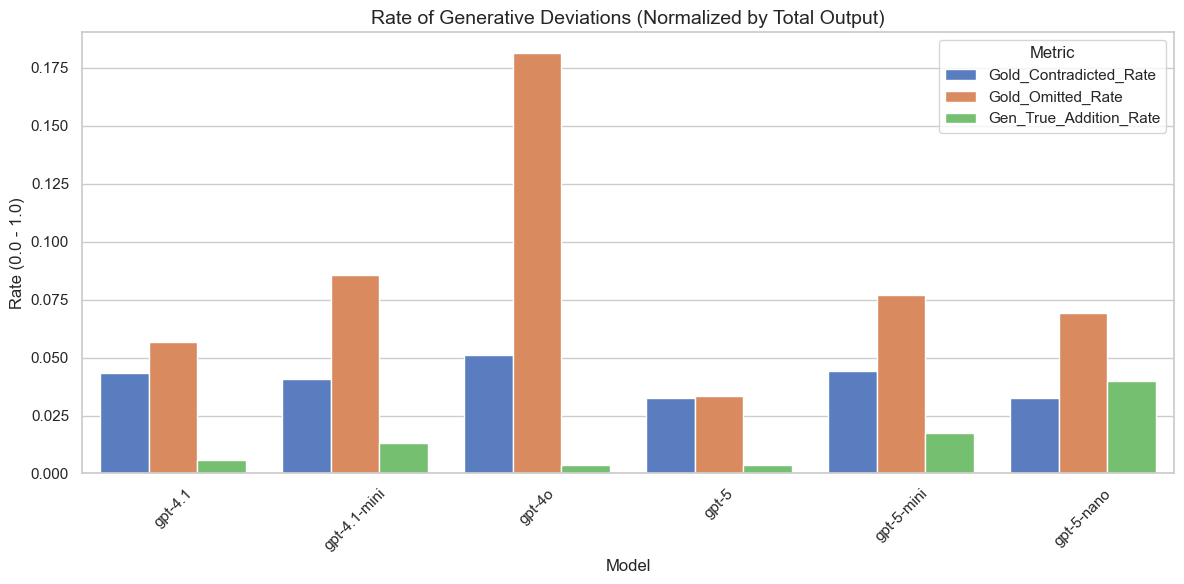

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt
# Set visual style
sns.set_theme(style="whitegrid")
metrics = ['Gold_Contradicted', 'Gold_Omitted', 'Gen_True_Addition']
plt.figure(figsize=(12, 6))

# Melt dataframe to long format for plotting
df_melted_counts = df_model.melt(
    id_vars='Model', 
    value_vars=metrics, 
    var_name='Metric', 
    value_name='Count'
)

sns.barplot(data=df_melted_counts, x='Model', y='Count', hue='Metric', palette='muted')
plt.title('Count of Generative Deviations by Model', fontsize=14)
plt.ylabel('Number of Facts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

rate_cols = []
for m in metrics:
    col_name = f'{m}_Rate'
    df_model[col_name] = df_model[m] / df_model['Gen_Total']
    rate_cols.append(col_name)

plt.figure(figsize=(12, 6))

# Melt for plotting
df_melted_rates = df_model.melt(
    id_vars='Model', 
    value_vars=rate_cols, 
    var_name='Metric', 
    value_name='Rate'
)

sns.barplot(data=df_melted_rates, x='Model', y='Rate', hue='Metric', palette='muted')
plt.title('Rate of Generative Deviations (Normalized by Total Output)', fontsize=14)
plt.ylabel('Rate (0.0 - 1.0)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd

file_path = r"E:\hallucination\Reducing-Hallucinations-in-Clinical-Diagnosis\detectionAG\Research_Paper_Metrics.xlsx"
df_model = pd.read_excel(file_path, sheet_name="Model_Overview")


df_model['Omission_Rate'] = df_model['Gold_Omitted'] / df_model['Gold_Total']

df_model['Contradiction_Rate'] = df_model['Gen_Contradicted'] / df_model['Gen_Total']

df_model['Addition_Rate'] = df_model['Gen_True_Addition'] / df_model['Gen_Total']

cols_to_show = ['Model', 'Omission_Rate', 'Contradiction_Rate', 'Addition_Rate']
print("--- Rates per Model ---")
print(df_model[cols_to_show])

print("\n--- Overall Averages ---")
print(df_model[['Omission_Rate', 'Contradiction_Rate', 'Addition_Rate']].mean())


--- Rates per Model ---
          Model  Omission_Rate  Contradiction_Rate  Addition_Rate
0       gpt-4.1       0.099920            0.057466       0.005882
1  gpt-4.1-mini       0.146400            0.061301       0.013102
2        gpt-4o       0.239459            0.059639       0.003614
3         gpt-5       0.065767            0.050600       0.003431
4    gpt-5-mini       0.136697            0.060147       0.017447
5    gpt-5-nano       0.145251            0.048271       0.039909

--- Overall Averages ---
Omission_Rate         0.138916
Contradiction_Rate    0.056237
Addition_Rate         0.013898
dtype: float64


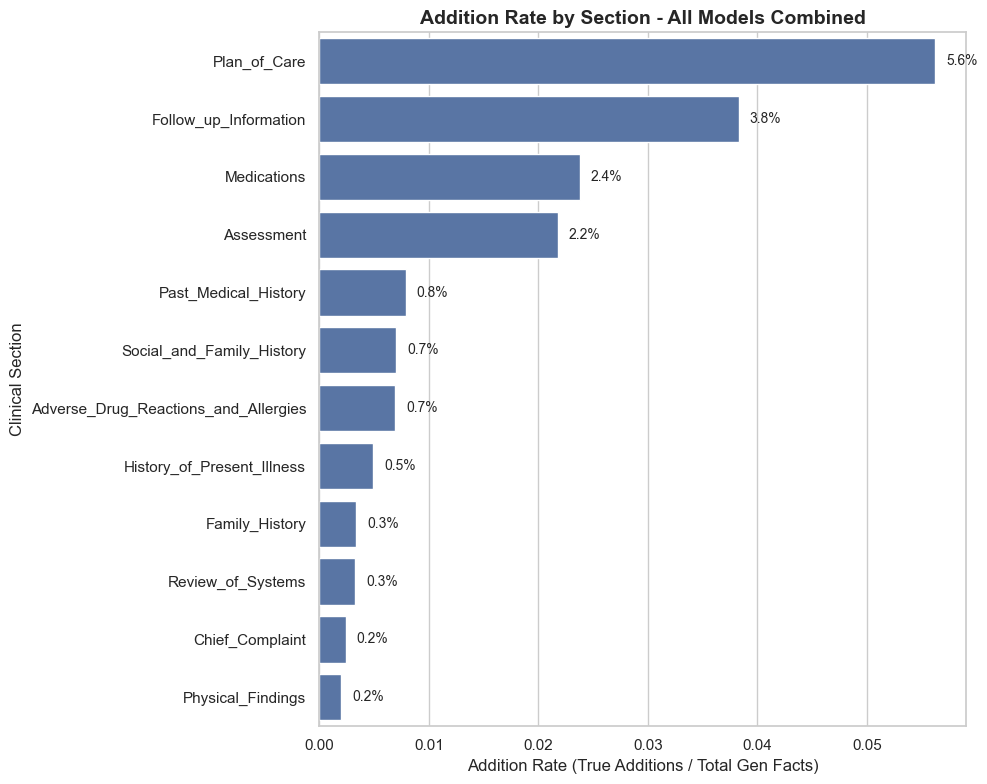

In [7]:
df_cats = pd.read_excel(INPUT_FILE_PATH, sheet_name="Category_Analysis")
df_cats = df_cats[df_cats['Gen_Total'] > 0].copy()

# 3. Aggregate Data Across All Models
# We sum the numerators and denominators first to get a weighted average
section_stats = df_cats.groupby('Category')[['Gen_Hallucinations', 'Gen_Total']].sum().reset_index()

# Calculate the Global Addition Rate
# Rate = Total Hallucinations (True Additions) / Total Facts Generated
section_stats['Global_Addition_Rate'] = section_stats['Gen_Hallucinations'] / section_stats['Gen_Total']

# Sort for the chart (Highest risk at the top)
section_stats = section_stats.sort_values('Global_Addition_Rate', ascending=False)

# 4. Create the Graph
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

barplot = sns.barplot(
    data=section_stats,
    y='Category',
    x='Global_Addition_Rate',
    color='#4c72b0'  # Standard professional blue
)

# 5. Styling
plt.title('Addition Rate by Section - All Models Combined', fontsize=14, fontweight='bold')
plt.xlabel('Addition Rate (True Additions / Total Gen Facts)', fontsize=12)
plt.ylabel('Clinical Section', fontsize=12)

# Optional: Add percentage labels to the bars
for i, v in enumerate(section_stats['Global_Addition_Rate']):
    barplot.text(v + 0.001, i, f'{v:.1%}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

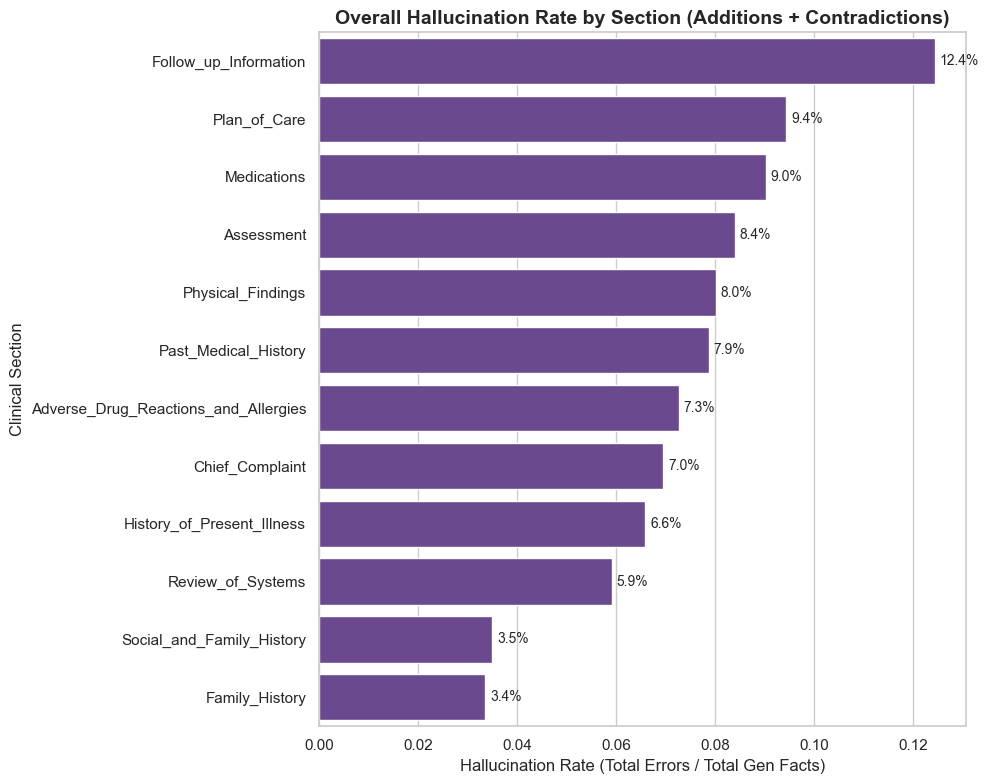

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Data

# Set visual style
sns.set_theme(style="whitegrid")

# ==============================================================================
# GRAPH: Overall Hallucination Rate by Section (Additions + Contradictions)
# ==============================================================================

# Filter valid generation rows
df_clean = df_cats[df_cats['Gen_Total'] > 0].copy()

# Calculate Total Hallucinations (Additions + Contradictions)
# We sum the raw counts first to ensure a correct weighted average
df_clean['Total_Error_Count'] = df_clean['Gen_Hallucinations'] + df_clean['Gen_Contradictions']

# Aggregate sums across all models per section
sec_stats = df_clean.groupby('Category')[['Total_Error_Count', 'Gen_Total']].sum().reset_index()

# Calculate Global Rate
sec_stats['Global_Hallucination_Rate'] = sec_stats['Total_Error_Count'] / sec_stats['Gen_Total']
sec_stats = sec_stats.sort_values('Global_Hallucination_Rate', ascending=False)

plt.figure(figsize=(10, 8))
barplot = sns.barplot(
    data=sec_stats,
    y='Category',
    x='Global_Hallucination_Rate',
    color='#6a3d9a'  # Purple to distinguish from individual error types
)

plt.title('Overall Hallucination Rate by Section (Additions + Contradictions)', fontsize=14, fontweight='bold')
plt.xlabel('Hallucination Rate (Total Errors / Total Gen Facts)', fontsize=12)
plt.ylabel('Clinical Section', fontsize=12)

# Add percentage labels for clarity
for i, v in enumerate(sec_stats['Global_Hallucination_Rate']):
    barplot.text(v + 0.001, i, f'{v:.1%}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

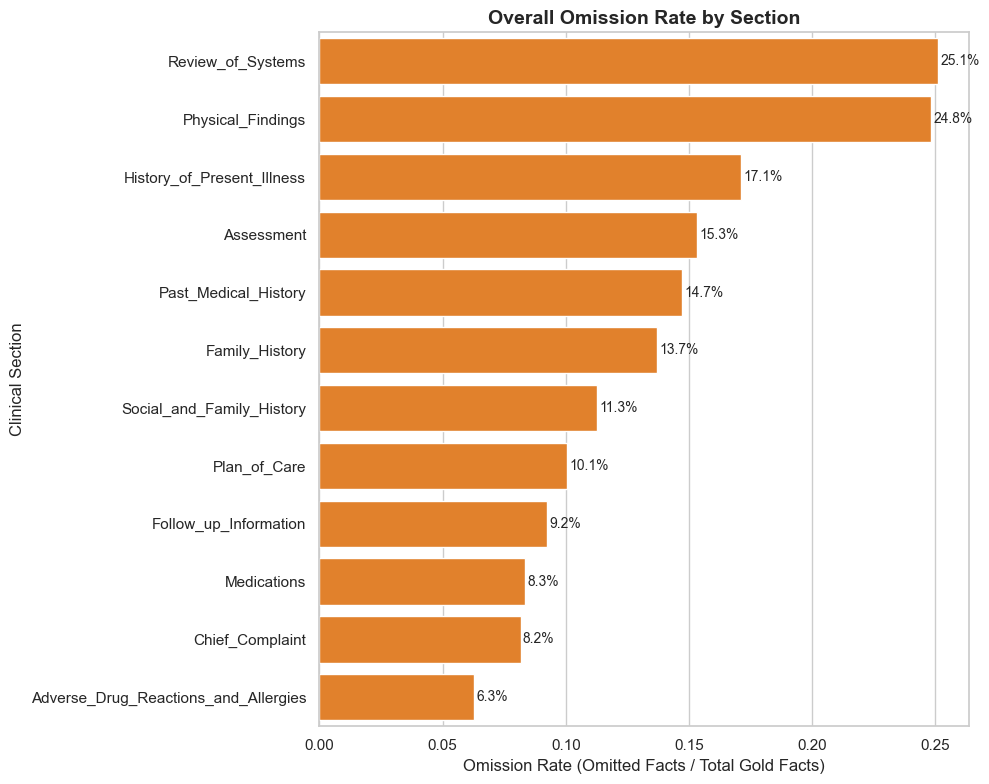

: 

In [ ]:
sns.set_theme(style="whitegrid")

# ==============================================================================
# GRAPH: Overall Omission Rate by Section
# ==============================================================================

# Filter valid gold rows (sections that actually had gold facts to miss)
# We only care about sections where there was something to find (Gold_Total > 0)
df_omit = df_cats[df_cats['Gold_Total'] > 0].copy()

# Aggregate sums across all models per section
# We sum first to ensure a correct weighted average across the entire dataset
omit_stats = df_omit.groupby('Category')[['Gold_Omissions', 'Gold_Total']].sum().reset_index()

# Calculate Global Omission Rate
omit_stats['Global_Omission_Rate'] = omit_stats['Gold_Omissions'] / omit_stats['Gold_Total']

# Sort for the chart (Highest omission risk at the top)
omit_stats = omit_stats.sort_values('Global_Omission_Rate', ascending=False)

# Create the plot
plt.figure(figsize=(10, 8))
barplot = sns.barplot(
    data=omit_stats,
    y='Category',
    x='Global_Omission_Rate',
    color='#ff7f0e'  # Orange to distinguish as 'Missing' info
)

plt.title('Overall Omission Rate by Section', fontsize=14, fontweight='bold')
plt.xlabel('Omission Rate (Omitted Facts / Total Gold Facts)', fontsize=12)
plt.ylabel('Clinical Section', fontsize=12)

# Add percentage labels for clarity
for i, v in enumerate(omit_stats['Global_Omission_Rate']):
    barplot.text(v + 0.001, i, f'{v:.1%}', va='center', fontsize=10)

plt.tight_layout()
plt.show()